# 【notebook｜N-04】tinyGPT 字符级预训练
> 对应：《03-Attention与Transformer.md》【文档｜DOC-3】、《05-训练循环与数据管线.md》【文档｜DOC-5】；代码 `F-b01-model`、`F-b02-pretrain`

> **对应理论篇**：[`03-Attention与Transformer.md`](../../01-基础/03-Attention与Transformer.md)、[`05-训练循环与数据管线.md`](../../01-基础/05-训练循环与数据管线.md)
> **对应 AlphaProof 源码**：`nanoproof/nanoproof/model.py`（模型）、`nanoproof/pretrain.py`（预训练循环）、`common.py:70` `GlobalConfig`
> **Colab**：CPU 可跑（micro 档约 1 分钟）；GPU 会自动加速。

## 学习目标
1. 用 `from_scratch/` 的极小 GPT 在字符级数学语料上做一次真实的 next-token 预训练；
2. 观察 loss 随 step 下降，并用采样看模型学到结构；
3. 理解 block 采样、teacher forcing、`x`/`y` 右移一位。


In [1]:
# 【N-04.c1】
!pip -q install torch --index-url https://download.pytorch.org/whl/cpu 2>/dev/null || pip -q install torch

In [2]:
# 【N-04.c2】
import os, sys
def find_code_dir():
    cands = ["../../01-基础/code/from_scratch", "01-基础/code/from_scratch",
             "../01-基础/code/from_scratch", "code/from_scratch"]
    for c in cands:
        if os.path.exists(os.path.join(c, "configs.py")):
            return os.path.abspath(c)
    cur = os.getcwd()
    for _ in range(8):
        c = os.path.join(cur, "01-基础", "code", "from_scratch", "configs.py")
        if os.path.exists(c):
            return os.path.dirname(c)
        cur = os.path.dirname(cur)
    raise FileNotFoundError("找不到 from_scratch 代码目录，请确认 v1.0 目录结构完整")

CODE_DIR = find_code_dir()
sys.path.insert(0, CODE_DIR)
print("代码目录:", CODE_DIR)


代码目录: /mnt/workspace/alphaproof-learn/stage/v1-stage/01-基础/code/from_scratch


## 理论回顾：自回归语言模型

把文本 token 化为一串 $x_1,\dots,x_N$，模型学习 $p_\theta(x_t\mid x_{<t})$。
训练目标是**教师强制**下的负对数似然：

$$
\mathcal{L}(\theta)=-\frac1{N}\sum_{t=1}^{N}\log p_\theta(x_t\mid x_{<t})
$$

实现上把同一段 token 同时当输入 $x_{1:T}$ 与标签 $x_{2:T+1}$（`y` 是 `x` 右移一位）。
困惑度 $\mathrm{PPL}=\exp(\mathcal{L})$ 可理解为「等效候选词数」。


## 实验 1：准备数据与模型

In [3]:
# 【N-04.c3】
import time, math, torch
from configs import get_config
from model import GPT
from data import prepare, get_batch

torch.manual_seed(1337)
device = "cuda" if torch.cuda.is_available() else "cpu"
cfg = get_config("micro")
tok, train_ds, val_ds, train_ids, val_ids = prepare(block_size=cfg.sequence_len)
cfg.vocab_size = tok.vocab_size
model = GPT(cfg).to(device)
print(f"device={device} | vocab={tok.vocab_size} | 参数={model.num_params()/1e6:.3f}M")
print("训练 token 数:", len(train_ids))
x, y = get_batch(train_ds, batch_size=4, device=device)
print("x[0,:20] =", tok.decode(x[0, :20].tolist()))
print("y[0,:20] =", tok.decode(y[0, :20].tolist()))


device=cuda | vocab=56 | 参数=0.102M
训练 token 数: 1089
x[0,:20] = n : Nat) : n + 0 = n
y[0,:20] =  : Nat) : n + 0 = n 


## 实验 2：训练（warmup + cosine，约 300 步）

In [4]:
# 【N-04.c4】
opt = model.configure_optimizers(
    weight_decay=0.1, learning_rate=3e-3, betas=(0.9, 0.95), device_type=device
)
max_iters, warmup, batch_size = 300, 30, 32
losses, t0 = [], time.time()

def lr_at(step):
    if step < warmup:
        return 3e-3 * (step + 1) / warmup
    prog = (step - warmup) / max(1, max_iters - warmup)
    return 3e-4 + 0.5 * (1 + math.cos(math.pi * prog)) * (3e-3 - 3e-4)

model.train()
for step in range(max_iters):
    lr = lr_at(step)
    for g in opt.param_groups:
        g["lr"] = lr
    x, y = get_batch(train_ds, batch_size, device)
    _, loss = model(x, y)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    losses.append(loss.item())
    if step % 50 == 0 or step == max_iters - 1:
        print(f"step {step:3d} loss {loss.item():.4f} lr {lr:.2e}")

print(f"完成，用时 {time.time()-t0:.1f}s，末步 loss {losses[-1]:.4f}")


step   0 loss 4.0277 lr 1.00e-04


step  50 loss 1.3407 lr 2.96e-03


step 100 loss 0.3750 lr 2.58e-03


step 150 loss 0.1457 lr 1.88e-03


step 200 loss 0.1117 lr 1.12e-03


step 250 loss 0.0843 lr 5.22e-04


step 299 loss 0.0909 lr 3.00e-04
完成，用时 4.2s，末步 loss 0.0909


## 实验 3：loss 曲线与采样

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 31526 (\N{CJK UNIFIED IDEOGRAPH-7B26}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 32423 (\N{CJK UNIFIED IDEOGRAPH-7EA7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas

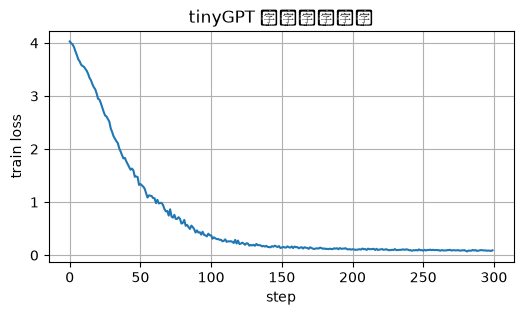

theorem mul_comm (a b : Nat) : a * b = b * a := by
  induction a with
  | zero => simp
  | succ a ih => rw [Nat.succ_mul, Nat.mu


In [5]:
# 【N-04.c5】
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6, 3))
    plt.plot(losses)
    plt.xlabel("step"); plt.ylabel("train loss"); plt.title("tinyGPT 字符级预训练")
    plt.grid(True); plt.show()
except Exception as e:
    print("(无 matplotlib，跳过绘图)", e)

model.eval()
g = torch.Generator(device=device).manual_seed(42)
prompt = "theorem "
ids = torch.tensor([tok.encode(prompt)], dtype=torch.long, device=device)
out = model.generate(ids, max_new_tokens=120, temperature=0.8, top_k=20, generator=g)
print(tok.decode(out[0].tolist()))


## 思考题

1. 为什么训练 loss 用「`x` 与右移一位的 `y`」就能实现教师强制？
2. `block_size` 增大对显存/计算的影响是线性的还是平方的（注意力部分）？
3. 采样时 temperature、top-k、top-p 分别控制什么？贪心（temperature=0）的缺点是什么？

## 改动实验（任选 2–3 个）
1. 把 `cfg = get_config("tiny")`，对比参数量与训练时间。
2. 把 `n_kv_head` 从 2 改成 4（MHA），loss 曲线有何变化？
3. 去掉 warmup（`warmup=0`），看前几十步 loss 是否震荡。
4. 把训练语料换成 `--text-file` 指定的英文文本（可调用 `prepare(text_path=...)`）。

## 预期输出
```
device=cpu | vocab=... | 参数=0.103M
step   0 loss 3.70 ...
step 299 loss 1.20 量级
完成，用时 ...s，末步 loss 1.2 量级
theorem ...（采样出类似 Lean 的片段，未训练充分时可能乱码）
```
loss 从 $\\ln(\\text{vocab})\\approx 4.2$ 附近下降；micro 档 300 步通常到 1.2–2.0。
